In [1]:
library(Signac)
library(Seurat)
library(ggplot2)
library(dplyr)
library(BuenColors)
library(GenomeInfoDb)
library(jsonlite)

Signac built for for SeuratObject v4 was just loaded with SeuratObject
v5; disabling v5 assays and validation routines, and ensuring assays
work in strict v3/v4 compatibility mode

Attaching SeuratObject

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: MASS


Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select


Warning message:
“package ‘GenomeInfoDb’ was built under R version 4.3.2”
Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.3.2”

Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff

In [2]:
setwd('/gpfs/commons/groups/vickovic_lab/rhe/projects/005/analysis_150424/scripts')

### Process CUT&Tag data

Read in counts matrix

In [3]:
# Read in CUT&Tag data as Signac object

counts <- Matrix::readMM("../data/peak_filtered/cutntag_230509_4/filtered_peak_bc_matrix/matrix.mtx")
barcodes <- readLines("../data/peak_filtered/cutntag_230509_4/filtered_peak_bc_matrix/barcodes.tsv")
peaks <- read.table("../data/peak_filtered/cutntag_230509_4/filtered_peak_bc_matrix/peaks.bed", sep="\t")
peaknames <- paste(peaks$V1, peaks$V2, peaks$V3, sep="-")

colnames(counts) <- barcodes
rownames(counts) <- peaknames

Load genomic annotations for Signac object

In [4]:
# We can't use the EnsDb packages as these are for mm10 rather than GrCm39

annotations <- rtracklayer::import("../data/Mus_musculus.GRCm39.110.gtf")
seqlevelsStyle(annotations) <- 'Ensembl'

annotations <- keepStandardChromosomes(annotations, pruning.mode="coarse")

genome(annotations) <- "GrCm39"
annotations$tx_id <- annotations$transcript_id

Create Signac object with fragments file

In [5]:
chrom_assay <- CreateChromatinAssay(
  counts = counts,
  sep = c(":", "-"),
  fragments = '../data/peak_filtered/cutntag_230509_1/cutntag_230509_1_frags.sorted.bed.gz',
  min.cells = 1,
  min.features = 1
)

cutntag <- CreateSeuratObject(
  counts = chrom_assay,
  assay = "cutntag_spatial",
  annotations = annotations
)

Computing hash



In [10]:
# Add image coordinates
fiducial <- fromJSON(txt='../data/peak_filtered/cutntag_230509_4/V12D14-323-D1.json')
coord_df <- read.table('../visium-v1_coordinates.txt', sep='\t', row.names=1)
colnames(coord_df) <- c('col','row')
coord_df[['barcode']] <- rownames(coord_df)

merged_res <- dplyr::left_join(coord_df, fiducial$oligo, by=c('col','row'))
coords_keep <- merged_res[!is.na(merged_res$tissue), c('col','row')]
rownames(coords_keep) <- merged_res[!is.na(merged_res$tissue),'barcode']

cutntag@images$image <-  new(
    Class = 'SlideSeq',
    assay = "cutntag_spatial",
    key = "image_",
    coordinates = coords_keep[WhichCells(cutntag),c('row','col')]
  )

Plot summary statistics

Scale for fill is already present.
Adding another scale for fill, which will replace the
existing scale.


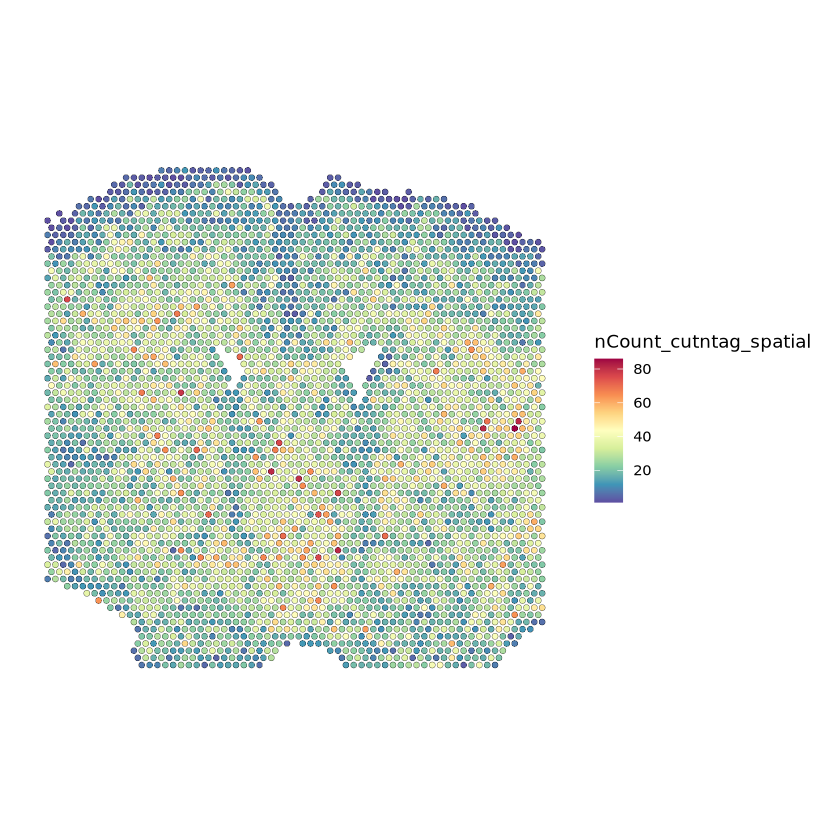

In [11]:
SpatialFeaturePlot(cutntag, features = "nCount_cutntag_spatial", pt.size.factor=3) + theme(legend.position = "right") + scale_fill_gradientn(colors=jdb_palette('brewer_spectra'))

Scale for fill is already present.
Adding another scale for fill, which will replace the
existing scale.


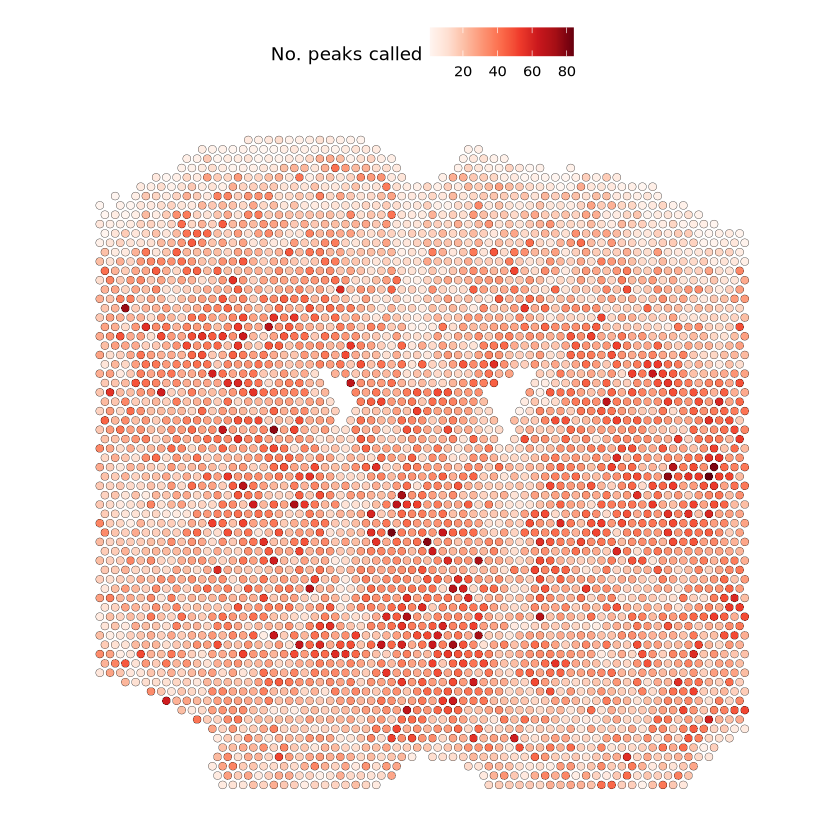

In [12]:
SpatialFeaturePlot(cutntag, features = "nFeature_cutntag_spatial", pt.size.factor=3) + 
  scale_fill_gradientn(colors=jdb_palette('brewer_red'), name='No. peaks called')